<a href="https://colab.research.google.com/github/88305Louise/cb2330-portfolio/blob/main/PRO1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The paper:** Llopart, A., Pettie, N., Ryon, E. and Comeron, J. M. (2025) The crossover landscape and interference in Drosophila santomea. PLoS Genetics 21:e1011885.
https://doi.org/10.1371/journal.pgen.1011885

**The data object:** The data used in this project was based on table 2 in the article, which shows the number of crossovers for five different chromosome types and the total number of crossovers for five different types of chromosome arms. Thie different crossoncers are NCO, meaning no or zero crossovers, 1CO, meaning one crossover, 2CO for two crossovers, 3CO for three crossovers and 4CO for four crossovers. The types chromosome arms are 2L, 2R^2, 3L, 3R and X.

**The random variable chosen:** The variable analysed in this notebook was the number of crossover events occuring on a chromosome arm in a randomly selected meiotic product.

**What the paper does:** The article presents a genome-wide, high-resolution crossover map for the fruit fly *Drosophila santomea* and compares it to other closely related fruit flies. The researshers examined 784 individual meiotic products that captured intraspecific variation in crossing over control and identified 2,288 genome-wide crossovers. The findings suggested a link between the intensity of crossover interference and the centromere effect, and the researchers proposed that "stronger crossover interference is associated with a smaller crossover-competent region—determined by the combined centromere and telomere effects—to prevent the deleterious consequences of multiple crossovers occurring too close together".

**The generative model proposed:** A poission distribution was proposed as a mechanism for how the crossovers happens. The mechanism is choosen based on the fact that the data is based on a set number of crossover event and measures the number of crossovers for each event.

**Parameters and assumptions:** The parameter theta was used to describe the average number of crossovers per crossover event and was assumed to (...) and the number of chromosome arms simulated was given the parameter N and was set to (...).

**The forward simulation:** The forward simulation was produced by performing a possion distribution according to the parameters theta and N, discussed in the previous pharagraph.

**The parameterization/fitting:** The parameter theta was fitted to the papers data by running a maximum likelihood on the total number of observed crossover event (denoted as observed_counts) for each type of crossover. The total number of observed crossover events were calculated as the sum of all five types of chromosome arms. The parameterization resulted in the fitted theta value theta_hat.

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

In [6]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Run it forward

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total


def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x colonies at rate theta."""
    p = (theta**x * math.exp(-theta))/ factorial(x)
    return p

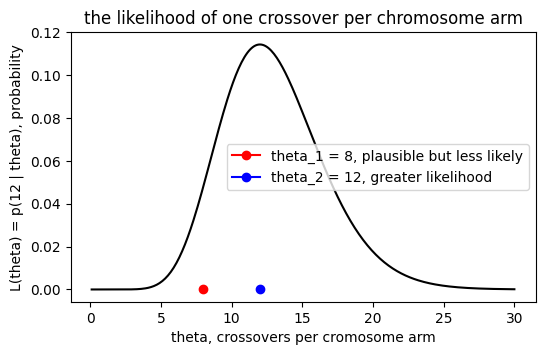

In [40]:
# Theta is the estimated mean of the number of crossovers per crossover event
# The article estimates this as 3.34
# N is the number of chromosome arms to simulate, we simulate 100 chromosome arms

thetas = [0.0] * 300
heights = [0.0] * 300
for j in range(300):
    thetas[j] = 0.1 * (j + 1)
    heights[j] = poisson(12, thetas[j])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thetas, heights, color="black")
ax.plot([8.0], [poisson(100, 3.34)], marker="o", color="red", label="theta_1 = 8, plausible but less likely")
ax.plot([12.0], [poisson(100, 3.34)], marker="o", color="blue", label="theta_2 = 12, greater likelihood")
ax.set_xlabel("theta, crossovers per cromosome arm")
ax.set_ylabel("L(theta) = p(12 | theta), probability")
ax.set_title("the likelihood of one crossover per chromosome arm")
ax.legend()
plt.show()

In [34]:
# Run it backwards by maximum likelihood
def likelihood(counts, theta):
    """L(theta) = the product over dishes of p(x_i | theta)."""
    total = 1.0
    for x in counts:
      total = total*poisson(x, theta)
    return total
# from the paper
# The right numbers are the crossover class and the left are the observed number of crossover for each class

observed_counts ={0: 1523, 1: 1451, 2: 340, 3: 43, 4: 7}

total_crossovers = likelihood(observed_counts, theta)

theta_hat = total_crossovers/N

print("Number of observations:", N)
print("Total crossover events:", total_crossovers)
print("Estimated theta:", theta_hat)

Number of observations: 120
Total crossover events: 1.1872399811818537e-05
Estimated theta: 9.893666509848781e-08


In [ ]:
# Test the model
# Bad as fuck

